In [1]:
# 1. Imports
%matplotlib ipympl
import os
import numpy as np
from scipy.ndimage import maximum_filter, minimum_filter, gaussian_filter
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print(matplotlib.get_backend())
from IPython.display import display
from scipy.ndimage import uniform_filter1d, maximum_filter1d, minimum_filter1d, maximum_filter, minimum_filter, rotate
from tqdm.auto import tqdm
from scipy.ndimage import distance_transform_edt  # distance (in pixels) to nearest seed pixel
from scipy.ndimage import convolve                # fast neighborhood averaging via convolution

ipympl


In [2]:
# 2. Parameters
LUT = {
    "wavelength_nm": np.arange(390, 701, 5),
    "mac_od": np.array([0.04533,0.06489,0.0868,0.112,0.1365,0.1631,0.1981,0.2345,0.2618,0.2772,0.2884,0.308,0.3332,0.3486,0.35,0.3269,0.2996,0.2842,0.2786,0.2772,0.2688,0.2485,0.2093,0.1652,0.1211,0.0812,0.0525,0.0329,0.0175,0.00929,0.00459,0.00166,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
    "lens_od": np.array([2.5122,2.1306,1.7649,1.4257,1.13738,0.9063,0.72398,0.59572,0.4876,0.4081,0.34132,0.29998,0.26288,0.2438,0.2279,0.21306,0.20458,0.19292,0.18338,0.1749,0.16748,0.16006,0.1537,0.14628,0.1378,0.12932,0.12296,0.1166,0.11024,0.10494,0.09858,0.09222,0.08586,0.0795,0.0742,0.06784,0.06148,0.05512,0.04876,0.04346,0.03812,0.03286,0.02968,0.02544,0.02226,0.01908,0.01696,0.01484,0.01166,0.00848,0.0053,0.00424,0.00318,0.00106,0,0,0,0,0,0,0,0,0]),
    "cone_ext_parameters": np.array([0.417050601,0.002072146099,0.0001638878333,-1.922880605,-16.05774461,0.001575425685,0.0000511375521,0.00157980964,0.00006584275242,0.00006684015221,0.002310441807,0.00007313131766,0.00001862685404,0.002008124081,0.00005407174451,0.00000514735556,0.001455412882,0.00004217635152,4.80E-06,0.001809022392,0.00003866766734,2.99E-05,0.001757314922,0.00001473437751,1.51E-05,0.35000001,0.1248091545,0.02274730785,0.0009731002994], dtype=float),
    "input_photopigment_peak_s": 419,
    "input_photopigment_peak_m": 530,
    "input_photopigment_peak_l": 557.25,
    "input_ODmax_s": 0.35,
    "input_ODmax_m": 0.3,
    "input_ODmax_l": 0.3,
    "primary_r": np.array([0.15,0.00,0.00,0.00,0.16,0.67,2.27,4.65,9.27,14.71,20.17,28.36,32.79,26.87,15.82,8.33,5.12,3.28,2.11,1.45,1.00,0.95,0.93,0.89,1.11,1.33,1.43,1.65,1.54,1.37,1.14,1.07,0.77,0.82,0.72,1.13,3.86,20.89,83.73,217.09,406.93,617.30,767.04,841.61,880.56,874.64,833.56,786.86,735.62,683.48,626.69,553.89,502.62,469.58,427.00,386.31,342.35,305.56,262.91,227.58,199.75,179.59,161.84]),
    "primary_g": np.array([0.00,0.05,0.00,0.00,0.00,0.00,0.12,0.55,1.63,4.60,10.72,23.07,37.52,47.36,55.72,71.12,99.87,123.43,131.23,127.34,142.58,174.86,227.38,285.70,388.61,508.82,621.44,644.47,712.30,760.29,789.32,789.25,751.83,742.14,687.43,630.10,573.19,490.28,411.33,330.16,246.74,173.14,111.25,64.28,34.18,16.73,8.20,4.39,2.64,1.83,1.34,1.16,0.95,0.78,0.69,0.72,0.80,1.00,1.15,1.54,2.07,2.67,3.44]),
    "primary_b": np.array([0.21,0.13,0.00,0.00,0.89,4.87,16.55,46.70,118.50,249.45,450.46,819.32,1234.87,1291.28,944.04,599.84,417.24,281.30,181.82,121.72,97.11,91.72,89.71,87.65,86.12,79.72,66.47,48.76,40.28,33.82,29.70,23.65,17.67,12.50,8.21,5.86,4.69,4.07,3.65,3.21,2.82,2.50,2.20,1.87,1.82,1.72,1.90,2.13,2.45,2.96,3.63,4.32,5.13,5.98,6.58,7.01,6.84,6.51,5.91,5.18,4.75,4.65,4.22]),
    "sigma_center": 0.025,
    "sigma_surround": 0.165,
    "surround_ratio_lm": np.array([1/2, 1/2]),
    "surround_ratio_lms": np.array([1/3, 1/3, 1/3]),
}

n = len(LUT["wavelength_nm"])
keys = ["mac_od", "lens_od", "primary_r", "primary_g", "primary_b"]
for k in keys:
    if len(LUT[k]) != n:
        raise ValueError(f"{k} has {len(LUT[k])} entries, expected {n}")
                     
    

In [3]:
# 3. Carroll cone extinction equation
ext_p = LUT["cone_ext_parameters"]
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXY")
p = dict(zip(letters, ext_p[:25]))

def _gauss(x, mu, sigma):
    return (1.0/np.sqrt(2.0*np.pi))*np.exp(-0.5*((x-mu)/sigma)**2)

def cone_log_extinction(wavelength_nm, lambda_max_nm, p, ref_nm=558.5):
    shift = np.log10(1.0/lambda_max_nm)-np.log10(1.0/ref_nm)
    x = 10.0**(np.log10(1.0/wavelength_nm)-shift)
    part1_inside = (-p["E"]+p["E"]*np.tanh(-((x-p["F"])/p["G"])))
    part1 = np.log10(part1_inside)+p["D"]+p["A"]*np.tanh(-((x-p["B"])/p["C"]))
    part2 = (
        -(p["J"]/p["I"])*_gauss(x,p["H"],p["I"])
        -(p["M"]/p["L"])*_gauss(x,p["K"],p["L"])
        -(p["P"]/p["O"])*_gauss(x,p["N"],p["O"])
        +(p["S"]/p["R"])*_gauss(x,p["Q"],p["R"])
        +(p["V"]/p["U"])*_gauss(x,p["T"],p["U"])/10.0
        +(p["Y"]/p["X"])*_gauss(x,p["W"],p["X"])/100.0
    )
    whole = part1+part2
    return whole
           

In [4]:
# 4. Compute cone extinction arrays
log_ext_s = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_s"], p)
log_ext_m = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_m"], p)
log_ext_l = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_l"], p)


In [5]:
# 5. effective cone spectral sensitivity with optical desity  
def apply_OD(cone_log_extinction, input_ODmax, mac_od, lens_od):
    cone_linear_extinction = 10.0**cone_log_extinction
    numerator = 1.0-10.0**(-(cone_linear_extinction*input_ODmax))
    denominator = 1.0 - 10.0**(-input_ODmax)
    step1 = np.log10(numerator/denominator)-lens_od-mac_od
    final = 10.0**(step1+2)
    return final

In [6]:
# 6. compute effective cone spectral sensitivity with optical desity
ext_s = apply_OD(log_ext_s, LUT["input_ODmax_s"], LUT["mac_od"], LUT["lens_od"])
ext_m = apply_OD(log_ext_m, LUT["input_ODmax_m"], LUT["mac_od"], LUT["lens_od"])
ext_l = apply_OD(log_ext_l, LUT["input_ODmax_l"], LUT["mac_od"], LUT["lens_od"])
ext_surround_lm = LUT["surround_ratio_lm"][0]*ext_m+LUT["surround_ratio_lm"][1]*ext_l

# Adding H2-connected mRGC model
ext_surround_lms = (LUT["surround_ratio_lms"][0]*ext_s+LUT["surround_ratio_lms"][1]*ext_m
                    +LUT["surround_ratio_lms"][2]*ext_l)

In [7]:
# 7. compute RGB primary quanta to white light [1,1,1] 
white = np.array([1.0,1.0,1.0])
yellow = np.array([1.0,1.0,0.0])
primaries = np.stack([LUT["primary_r"],LUT["primary_g"],LUT["primary_b"]], axis=1)
primary_white = (white*primaries).sum(axis=1)
primary_yellow = (yellow*primaries).sum(axis=1)
total_quanta_white = primary_white.sum()
total_quanta_yellow = primary_yellow.sum()

## alternative that uses the integral
# dlambda = LUT["wavelength_nm"][1] - LUT["wavelength_nm"][0]  # should be 5 nm
# total_quanta_white = primary_white.sum()*dlambda
# total_quanta_yellow = primary_yellow.sum()*dlambda


In [8]:
# 8. Find scalar to equalize total quantal response of L- and M-center to LM-surround

response_white_lm = np.sum(ext_surround_lm*primary_white)
response_white_l = np.sum(ext_l*primary_white)
response_white_m = np.sum(ext_m*primary_white)
response_white_s = np.sum(ext_s*primary_white) # Adding H2-connected mRGC model
response_white_lms = np.sum(ext_surround_lms*primary_white) # Adding H2-connected mRGC model

scalar_l = response_white_lm/response_white_l
scalar_m = response_white_lm/response_white_m
scalar_s = response_white_lm/response_white_s # Adding H2-connected mRGC model
scalar_lms = response_white_lm/response_white_lms # Adding H2-connected mRGC model

response_yellow_lm = np.sum(ext_surround_lm*primary_yellow)
response_yellow_l = np.sum(ext_l*primary_yellow)
response_yellow_m = np.sum(ext_m*primary_yellow)


In [9]:
# 9. Build 2D gaussian (and DoGs) receptive fields
radius = 1.05 # degrees
dx = 0.005 # pixels per degree
x = np.arange(-radius, radius+dx, dx)
X,Y = np.meshgrid(x,x)

# spatial kernal 
amp_center = 1.0
amp_surround = amp_center*(LUT["sigma_center"]**2)/(LUT["sigma_surround"]**2)

def gaussian_2D(X,Y,amp,sigma):
    return amp*np.exp(-(X**2+Y**2)/(2*sigma**2))

gaussian_center = gaussian_2D(X,Y,amp_center,LUT["sigma_center"])
gaussian_surround = gaussian_2D(X,Y,amp_surround,LUT["sigma_surround"])

rf_on = gaussian_center-gaussian_surround
rf_off = -rf_on

In [10]:
# 9b sanity check
integral_center = gaussian_center.sum()*dx*dx
integral_surround = gaussian_surround.sum()*dx*dx
print(integral_center, integral_surround, integral_center/integral_surround)
print(amp_surround)

print(scalar_l*response_white_l, response_white_lm)
print(scalar_m*response_white_m, response_white_lm)
print(scalar_s*response_white_s, scalar_lms*response_white_lms) # Adding H2-connected mRGC model

0.00392699081698741 0.003926990815587744 1.000000000356422
0.022956841138659322
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184


In [11]:
# 10. check response under full white [1,1,1], or yellow [1,1,0], compute uniform field responses
dog_response_l_white = ((scalar_l*response_white_l)*gaussian_center.sum()*dx*dx-
                        (response_white_lm)*gaussian_surround.sum()*dx*dx)
dog_response_m_white = ((scalar_m*response_white_m)*gaussian_center.sum()*dx*dx-
                        (response_white_lm)*gaussian_surround.sum()*dx*dx)
dog_response_h2_white = ((scalar_s*response_white_s)*gaussian_center.sum()*dx*dx-
                         (scalar_lms*response_white_lms)*gaussian_surround.sum()*dx*dx)


dog_response_l_yellow = ((scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx-
                         (response_yellow_lm)*gaussian_surround.sum()*dx*dx)
dog_response_m_yellow = ((scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx-
                         (response_yellow_lm)*gaussian_surround.sum()*dx*dx)

print("L center under white light: ", (scalar_l*response_white_l)*gaussian_center.sum()*dx*dx)
print("M center under white light: ", (scalar_m*response_white_m)*gaussian_center.sum()*dx*dx)
print("surround under white light: ", (response_white_lm)*gaussian_surround.sum()*dx*dx)
print("DoG under white light (L-center, M-center, H2): ", dog_response_l_white, dog_response_m_white, dog_response_h2_white)
print("L center under yellow light: ", (scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx)
print("M center under yellow light: ", (scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx)
print("surround under yellow light: ", (response_yellow_lm)*gaussian_surround.sum()*dx*dx)
print("DoG under yellow light (L-center, M-center): ", dog_response_l_yellow, dog_response_m_yellow)
print("Percentage of center, DoG under yellow light (L-center, M-center): ", 
      dog_response_l_yellow/((scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx), 
      dog_response_m_yellow/((scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx))


L center under white light:  4537.338264696156
M center under white light:  4537.338264696156
surround under white light:  4537.338263078949
DoG under white light (L-center, M-center, H2):  1.617207090021111e-06 1.617207090021111e-06 1.617207090021111e-06
L center under yellow light:  4234.125064542216
M center under yellow light:  3980.384448817143
surround under yellow light:  4124.127673848554
DoG under yellow light (L-center, M-center):  109.99739069366206 -143.74322503141093
Percentage of center, DoG under yellow light (L-center, M-center):  0.02597877696500085 -0.03611289986677727


In [12]:
# 11. FFT 2D convolution
def fft_2d(image, kernel, pad_mode="reflect"):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    Ih,Iw = image.shape
    Kh,Kw = kernel.shape
    pady = Kh//2
    padx = Kw//2
    imgpad = np.pad(image, ((pady,pady), (padx,padx)),mode=pad_mode)
    Ph,Pw = imgpad.shape
    out_shape = (Ph+Kh-1, Pw+Kw-1)
    # k0 = np.fft.ifftshift(kernel)
    y = np.fft.ifft2(np.fft.fft2(imgpad, out_shape)*np.fft.fft2(kernel, out_shape)).real
    r0 = Kh//2
    c0 = Kw//2
    convpad = y[r0:r0+Ph, c0:c0+Pw]
    return convpad[pady:pady+Ih, padx:padx+Iw]


In [13]:
# 12. create functions for the rgb images and responses by mRGCs

Ih = Iw = 1000
# (cy,cx) = (Ih//2,Iw//2)
yy = np.arange(Ih)
xx = np.arange(Iw)
X,Y = np.meshgrid(xx,yy)

# cone drive
weightl = np.array([np.sum(ext_l*LUT["primary_r"]),np.sum(ext_l*LUT["primary_g"]),np.sum(ext_l*LUT["primary_b"])],dtype=float)
weightm = np.array([np.sum(ext_m*LUT["primary_r"]),np.sum(ext_m*LUT["primary_g"]),np.sum(ext_m*LUT["primary_b"])],dtype=float)
weights = np.array([np.sum(ext_s*LUT["primary_r"]),np.sum(ext_s*LUT["primary_g"]),np.sum(ext_s*LUT["primary_b"])],dtype=float)
weightsurround = np.array([np.sum(ext_surround_lm*LUT["primary_r"]),
                           np.sum(ext_surround_lm*LUT["primary_g"]),np.sum(ext_surround_lm*LUT["primary_b"])],dtype=float)
weightsurround_h2 = np.array([np.sum(ext_surround_lms*LUT["primary_r"]),
                              np.sum(ext_surround_lms*LUT["primary_g"]),np.sum(ext_surround_lms*LUT["primary_b"])],dtype=float)

def draw_circle_img(Ih,Iw,X,Y,colorbg,colorcenter,kind="flat"):
    (cy,cx) = (Ih//2,Iw//2)
    r2 = (Y-cy)**2+(X-cx)**2
    R = (Ih//4)
    mask = r2<=R**2 
    img = np.broadcast_to(colorbg,(Ih,Iw,3)).copy()
    if kind == "flat":
        img[mask] = colorcenter
    elif kind == "gaussian":
        x01 = (X-(cx-R))/(2.0*R)
        npeaks = 5
        phase = 2.0*np.pi*npeaks*x01
        amp = 0.5*(1.0+np.cos(phase))
        img[mask] = amp[mask,None]*colorcenter
    else:
        raise ValueError(f"Unknown kind='{kind}'. Use 'flat' or 'gaussian'.")
    return img

def img2drive(img,weight):
    drive = img[...,0]*weight[0]+img[...,1]*weight[1]+img[...,2]*weight[2]
    return drive

def run_model(img):
    drivel = img2drive(img,weightl)
    drivem = img2drive(img,weightm)
    drives = img2drive(img,weights)
    drivesurround = img2drive(img,weightsurround)
    drivesurround_h2 = img2drive(img,weightsurround_h2)
    
    center_l = fft_2d(drivel, gaussian_center)
    center_m = fft_2d(drivem, gaussian_center)
    center_s = fft_2d(drives, gaussian_center) 
    surround = fft_2d(drivesurround, gaussian_surround)
    surround_h2 = fft_2d(drivesurround_h2, gaussian_surround) 
    
    respl_on = scalar_l*center_l-surround
    respm_on = scalar_m*center_m-surround
    respl_off = -respl_on
    respm_off = -respm_on

    respl_h2_on = (scalar_l*center_l+scalar_lms*surround_h2)-(scalar_s*center_s+surround) # Adding H2-connected mRGC model
    respm_h2_on = (scalar_m*center_m+scalar_lms*surround_h2)-(scalar_s*center_s+surround) # Adding H2-connected mRGC model
    respl_h2_off = -respl_h2_on # Adding H2-connected mRGC model
    respm_h2_off = -respm_h2_on # Adding H2-connected mRGC model
    
    return {"l_on": respl_on, "l_off": respl_off, 
            "m_on": respm_on, "m_off": respm_off,
            "l_h2_on": respl_h2_on, "m_h2_on": respm_h2_on,
            "l_h2_off": respl_h2_off, "m_h2_off": respm_h2_off}
    
# margin = gaussian_surround.shape[0] // 2
# core_m_h2 = respm_h2_on[margin:-margin, margin:-margin]
# core_l_h2 = respl_h2_on[margin:-margin, margin:-margin]
# print("M-center ON mRGC with H2 connection: ", core_m_h2.min(), core_m_h2.max(), core_m_h2.mean())
# print("L-center ON mRGC with H2 connection: ", core_l_h2.min(), core_l_h2.max(), core_l_h2.mean())

In [14]:
# 13. Create rgb image set and their mRGC responses

colorbg = [np.array([0.5,0.5,0.5], dtype=float), #gray
    # np.array([1,0,1], dtype=float), #magenta
    # np.array([0,1,1], dtype=float), #teal
    np.array([0,0,0], dtype=float)] #black
    
colorcenter = [np.array([1,1,1], dtype=float), #white
    np.array([0,0,1], dtype=float), #blue
    np.array([0,1,0], dtype=float), #green
    np.array([1,0,0], dtype=float), #red
    np.array([0.5,0,0], dtype=float), # medium red
    np.array([0.2,0,0], dtype=float), # light red  
    np.array([1,1,1], dtype=float), # light yellow 
    np.array([0.5,0.5,0], dtype=float), # light yellow            
    np.array([0.2,0.2,0], dtype=float)] #yellow           

kinds = ["flat", "gaussian"]

results = []
for cb in colorbg:
    for cc in colorcenter:
        for kind in kinds:
            img = draw_circle_img(Ih,Iw,X,Y,cb,cc,kind=kind)
            outs = run_model(img)
            results.append({"colorbg": cb, "colorcenter": cc, "imgs": img, "outs": outs})

In [15]:
# 14. mimic microsaccades (compare within radius)
# microsaccade frequency ~1 per sec
# microsaccade distance ~0.5 degrees
# perceptual fading "several seconds"
shiftpx = 50 # original = 50 0.25 degrees / 0.005 degrees per pixel
eps = 2e5 # tolerance for response magnitude comparisons

keys_order = ["l_on", "l_off", "m_on", "m_off", "l_h2_on", "m_h2_on", "l_h2_off", "m_h2_off"]

def disk(r):
    yy,xx = np.ogrid[-r:r+1, -r:r+1]
    return (xx*xx + yy*yy) <= (r*r)

FP = disk(shiftpx)

def dccouple(resp, eps=eps, footprint=FP):
    # neighborhood extrema
    maxv = maximum_filter(resp,footprint=footprint,mode="reflect")
    minv = minimum_filter(resp,footprint=footprint,mode="reflect")
    nochange = (maxv-minv) < eps # positions with no change in reponse in footprint

    out = np.where(np.abs(minv) > np.abs(maxv),minv,maxv) # value with greatest magnitude in footprint
    out[nochange] = 0.0
    return out

total = len(results)*len(keys_order)
pbar = tqdm(total=total, desc="DC-coupling (stimuli × mRGCs)") # code by ChatGTP

for r in results:
    outs = r["outs"]
    outsdc = {}
    for k in keys_order:         
        outsdc[k] = dccouple(outs[k])
        pbar.update(1)
    r["outsdc"] = outsdc

pbar.close()


DC-coupling (stimuli × mRGCs):   0%|          | 0/288 [00:00<?, ?it/s]

In [16]:
# 15a. Filling-in stage: step 1

sigma_px = 0.5          # original: 0.5 ; smoothing 
amp_thresh = 0.0        # optional: ignore tiny-amplitude extrema (set >0 if get clutter) 
grad_tol_frac = 0.7     # how close to “derivative = 0” (smaller = stricter)
curv_tol_frac = 0.20    # original value: 0.1. How strong curvature must be (bigger = stricter)

def ridge_valley_mask(A, amp_thresh=0.0, grad_tol_frac=0.02, curv_tol_frac=0.10):
    A = np.asarray(A, dtype=float)  # ensure float array

    gy, gx = np.gradient(A)         # first derivatives
    gxx = np.gradient(gx, axis=1)   # second derivative d2/dx2
    gyy = np.gradient(gy, axis=0)   # second derivative d2/dy2
    gxy = np.gradient(gx, axis=0)   # mixed derivative d2/(dx dy)

    tr  = gxx + gyy                 # Hessian trace
    det = gxx * gyy - gxy * gxy     # Hessian determinant
    tmp = np.sqrt(np.maximum(0.0, (0.5 * tr) ** 2 - det))  # eigen helper

    lam1 = 0.5 * tr - tmp           # smaller eigenvalue (more negative curvature)
    lam2 = 0.5 * tr + tmp           # larger eigenvalue (more positive curvature)

    vx1 = gxy                       # eigenvector x-component (one valid form)
    vy1 = lam1 - gxx                # eigenvector y-component
    nrm = np.hypot(vx1, vy1) + 1e-12# normalize safely
    vx1 /= nrm
    vy1 /= nrm

    d1 = gx * vx1 + gy * vy1        # directional derivative along v1

    grad_ref = np.percentile(np.abs(d1), 99)     # robust scale for gradient
    curv_ref = np.percentile(np.abs(lam1), 99)   # robust scale for curvature
    grad_tol = grad_tol_frac * grad_ref          # tolerance for “~0 derivative”
    curv_tol = curv_tol_frac * curv_ref          # required curvature magnitude

    ridge_max = (np.abs(d1) < grad_tol) & (lam1 < -curv_tol) & (np.abs(A) > amp_thresh)  # bright ridge

    vx2 = -vy1                      # orthogonal direction to v1 
    vy2 =  vx1
    d2 = gx * vx2 + gy * vy2        # directional derivative along v2

    valley_min = (np.abs(d2) < grad_tol) & (lam2 > curv_tol) & (np.abs(A) > amp_thresh)  # dark valley

    return ridge_max | valley_min   # extrema-like mask (ridges + valleys)

# ----------------------------
# Smooth ALL outsdc responses + compute extrema masks 
for r in results:
    outsdc_smooth = {}
    outsdc_extrema_mask = {}
    outsdc_extrema_coords = {}
    outsdc_extrema_weighted = {}  # store mask*outsdc values (peaks carry values, others 0)
    for k in keys_order:
        A = r["outsdc"][k]  # DC-coupled response
        As = gaussian_filter(A, sigma=sigma_px, mode="reflect")  # smoothed DC-coupled
        outsdc_smooth[k] = As
        m = ridge_valley_mask(As, amp_thresh=amp_thresh, grad_tol_frac=grad_tol_frac, curv_tol_frac=curv_tol_frac)  # mask
        outsdc_extrema_mask[k] = m
        outsdc_extrema_coords[k] = np.argwhere(m)  # (row, col) coords
        outsdc_extrema_weighted[k] = A * m.astype(float)  # keep DC values only where mask==True
    r["outsdc_smooth"] = outsdc_smooth
    r["outsdc_extrema_mask"] = outsdc_extrema_mask
    r["outsdc_extrema_coords"] = outsdc_extrema_coords
    r["outsdc_extrema_weighted"] = outsdc_extrema_weighted  # attach weighted images

# ----------------------------
# Smooth ALL RAW outs responses + compute extrema masks
for r in results:
    outs_smooth = {}
    outs_extrema_mask = {}
    outs_extrema_coords = {}
    outs_extrema_weighted = {}  # store mask*raw values (peaks carry values, others 0)
    for k in keys_order:
        A = r["outs"][k]  # RAW response
        As = gaussian_filter(A, sigma=sigma_px, mode="reflect")  # smoothed RAW
        outs_smooth[k] = As
        m = ridge_valley_mask(As, amp_thresh=amp_thresh, grad_tol_frac=grad_tol_frac, curv_tol_frac=curv_tol_frac)  # mask
        outs_extrema_mask[k] = m
        outs_extrema_coords[k] = np.argwhere(m)  # (row, col) coords
        outs_extrema_weighted[k] = A * m.astype(float)  # keep RAW values only where mask==True
    r["outs_smooth"] = outs_smooth
    r["outs_extrema_mask"] = outs_extrema_mask
    r["outs_extrema_coords"] = outs_extrema_coords
    r["outs_extrema_weighted"] = outs_extrema_weighted  # attach weighted images


[TS] i=1, key=l_on, seed_source=outsdc
[TS] % pick outsdc in A_comb =  45.36%
[TS] % seeds (W!=0)      =   0.99%
[TS] % updated (A==0)    =   0.00%
[TS] % updated (W==0)    =  95.32%


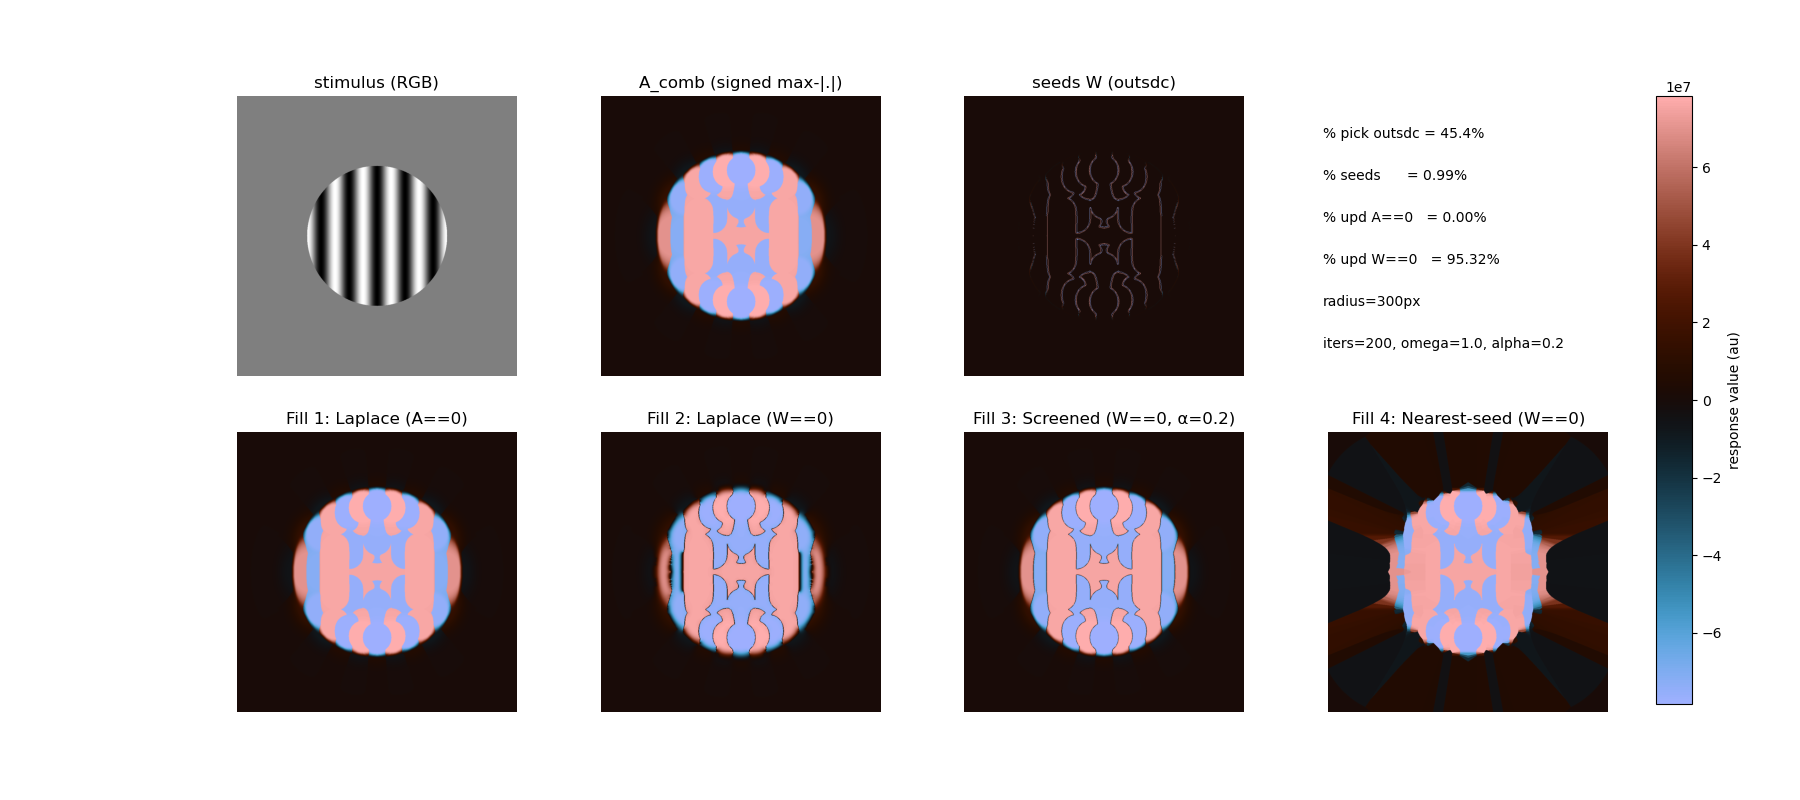

In [17]:
# --- 15b TROUBLESHOOTING CELL: compare fill strategies side-by-side (erase later)

# ----------------------------
# USER SETTINGS (edit these, rerun cell)
i = 1                         # TS: which stimulus index to test
k = "l_on"                    # TS: which response key to test (e.g., "l_h2_on")
seed_source = "outsdc"        # TS: "outsdc" or "raw" or "combined"
fill_radius_px = 300          # TS: max distance from seeds to fill
n_iters = 200                 # TS: diffusion iterations
omega = 1.0                   # TS: relaxation (1.0 safe)
alpha = 0.2                   # TS: screened diffusion strength (0 = pure Laplace)

# ----------------------------
# 4-neighbor Laplace stencil (up/down/left/right average)
K4 = np.array([[0, 1, 0],     # TS: neighbor weights
               [1, 0, 1],
               [0, 1, 0]], dtype=float) / 4.0

# ----------------------------
# TS: combine outs + outsdc by signed max-|value| (per-pixel)
def combine_outs_outsdc_signed_maxabs(outs_img, outsdc_img):
    outs_img = np.asarray(outs_img, dtype=float)                 # TS: ensure float
    outsdc_img = np.asarray(outsdc_img, dtype=float)             # TS: ensure float
    pick_dc = (np.abs(outsdc_img) > np.abs(outs_img))            # TS: where outsdc has bigger magnitude
    A_comb = np.where(pick_dc, outsdc_img, outs_img)             # TS: keep the winning signed value
    return A_comb, pick_dc                                       # TS: also return pick mask for diagnostics

# ----------------------------
# TS: diffusion / Poisson-style fill (two update-mask intents + optional screened term)
def diffusion_fill(A, W, radius_px=300, n_iters=200, omega=1.0,
                   intent="A==0", init_mode="A", alpha=0.0):
    A = np.asarray(A, dtype=float)                               # TS: base image (fill values / prior)
    W = np.asarray(W, dtype=float)                               # TS: seeds (anchors)

    seed_mask = (W != 0.0)                                       # TS: True where seeds exist
    if not np.any(seed_mask):                                    # TS: if no seeds, nothing to propagate
        return A.copy(), seed_mask, np.zeros_like(seed_mask)     # TS: return A + empty masks

    dist = distance_transform_edt(~seed_mask)                    # TS: distance to nearest seed
    in_radius = (dist <= float(radius_px))                       # TS: restrict fill region by radius

    if intent == "A==0":
        update_mask = (A == 0.0)                                 # TS: only fill pixels where A is exactly 0
        update_mask = update_mask & (~seed_mask)                 # TS: never update seeds
        update_mask = update_mask & in_radius                    # TS: only within radius
    elif intent == "W==0":
        update_mask = (~seed_mask) & in_radius                   # TS: fill ALL non-seed pixels within radius
    else:
        raise ValueError("intent must be 'A==0' or 'W==0'")       # TS: guardrail

    U = A.copy()                                                 # TS: working solution
    if init_mode == "zero":
        U[update_mask] = 0.0                                     # TS: start fill region from 0
    elif init_mode == "A":
        U[update_mask] = A[update_mask]                          # TS: start fill region from A (keeps structure)
    else:
        raise ValueError("init_mode must be 'zero' or 'A'")       # TS: guardrail

    U[seed_mask] = W[seed_mask]                                  # TS: clamp seeds before iterating

    for _ in range(int(n_iters)):                                # TS: iterate diffusion
        nbr_avg = convolve(U, K4, mode="reflect")                 # TS: Laplace update = neighbor average
        if alpha > 0.0:
            U_prop = (nbr_avg + alpha * A) / (1.0 + alpha)        # TS: screened diffusion (pull toward A)
        else:
            U_prop = nbr_avg                                      # TS: pure Laplace diffusion

        U_old = U[update_mask]                                    # TS: current fill values
        U_new = U_prop[update_mask]                               # TS: proposed fill values
        U[update_mask] = (1.0 - omega) * U_old + omega * U_new    # TS: relaxed update
        U[seed_mask] = W[seed_mask]                               # TS: re-clamp seeds every iter

    return U, seed_mask, update_mask                              # TS: return filled + masks

# ----------------------------
# TS: nearest-seed (Voronoi) fill (fast alternative to diffusion)
def nearest_seed_fill(A, W, radius_px=300, intent="A==0"):
    A = np.asarray(A, dtype=float)                                # TS: base image
    W = np.asarray(W, dtype=float)                                # TS: seeds

    seed_mask = (W != 0.0)                                        # TS: seed locations
    if not np.any(seed_mask):                                     # TS: no seeds -> nothing to do
        return A.copy(), seed_mask, np.zeros_like(seed_mask)      # TS: return A + empty masks

    dist, inds = distance_transform_edt(~seed_mask, return_indices=True)  # TS: nearest seed indices
    in_radius = (dist <= float(radius_px))                        # TS: only fill within radius

    if intent == "A==0":
        update_mask = (A == 0.0) & (~seed_mask) & in_radius        # TS: fill only A==0 pixels near seeds
    elif intent == "W==0":
        update_mask = (~seed_mask) & in_radius                     # TS: fill all non-seeds near seeds
    else:
        raise ValueError("intent must be 'A==0' or 'W==0'")         # TS: guardrail

    nearest_vals = W[inds[0], inds[1]]                              # TS: value of nearest seed (ties ignored)
    U = A.copy()                                                    # TS: output
    U[seed_mask] = W[seed_mask]                                     # TS: keep seeds fixed
    U[update_mask] = nearest_vals[update_mask]                      # TS: assign nearest-seed values

    return U, seed_mask, update_mask                                # TS: return filled + masks

# ----------------------------
# TS: pull the chosen stimulus + responses
r = results[i]                                                      # TS: selected stimulus dict
stim = r["imgs"]                                                    # TS: RGB stimulus image

outs_img = r["outs"][k]                                             # TS: raw response
outsdc_img = r["outsdc"][k]                                         # TS: dc response
A_comb, pick_dc = combine_outs_outsdc_signed_maxabs(outs_img, outsdc_img)  # TS: combined fill-values map

# TS: choose seeds W
if seed_source == "outsdc":
    W = r["outsdc_extrema_weighted"][k]                              # TS: DC seeds (mask × outsdc)
elif seed_source == "raw":
    W = r["outs_extrema_weighted"][k]                                # TS: RAW seeds (mask × outs)
elif seed_source == "combined":
    W = A_comb * (r["outsdc_extrema_mask"][k].astype(float))          # TS: combined values but using DC mask
else:
    raise ValueError("seed_source must be 'outsdc', 'raw', or 'combined'") # TS: guardrail

# ----------------------------
# TS: run all strategies (all use A_comb as A)
fill1, seed_mask, upd1 = diffusion_fill(A_comb, W, radius_px=fill_radius_px, n_iters=n_iters, omega=omega,
                                       intent="A==0", init_mode="A", alpha=0.0)            # TS: Laplace, fill A==0
fill2, _,        upd2 = diffusion_fill(A_comb, W, radius_px=fill_radius_px, n_iters=n_iters, omega=omega,
                                       intent="W==0", init_mode="A", alpha=0.0)            # TS: Laplace, fill W==0
fill3, _,        upd3 = diffusion_fill(A_comb, W, radius_px=fill_radius_px, n_iters=n_iters, omega=omega,
                                       intent="W==0", init_mode="A", alpha=alpha)          # TS: Screened, fill W==0
fill4, _,        upd4 = nearest_seed_fill(A_comb, W, radius_px=fill_radius_px, intent="W==0")# TS: Nearest-seed, fill W==0

# ----------------------------
# TS: diagnostics to explain why A_comb may "look like outsdc"
pct_pick_dc = 100.0 * float(pick_dc.mean())                          # TS: % pixels where outsdc beats outs by |.|
pct_seed = 100.0 * float(seed_mask.mean())                           # TS: % seed pixels
pct_upd1 = 100.0 * float(upd1.mean())                                # TS: % pixels updated in strategy 1
pct_upd2 = 100.0 * float(upd2.mean())                                # TS: % pixels updated in strategy 2

print(f"[TS] i={i}, key={k}, seed_source={seed_source}")
print(f"[TS] % pick outsdc in A_comb = {pct_pick_dc:6.2f}%")
print(f"[TS] % seeds (W!=0)      = {pct_seed:6.2f}%")
print(f"[TS] % updated (A==0)    = {pct_upd1:6.2f}%")
print(f"[TS] % updated (W==0)    = {pct_upd2:6.2f}%")

# ----------------------------
# TS: shared symmetric color scale for response-like panels
absmax = max(float(np.max(np.abs(A_comb))),
             float(np.max(np.abs(W))),
             float(np.max(np.abs(fill1))),
             float(np.max(np.abs(fill2))),
             float(np.max(np.abs(fill3))),
             float(np.max(np.abs(fill4))))                            # TS: max magnitude across panels
vmin, vmax = -absmax, absmax                                         # TS: symmetric limits

# ----------------------------
# TS: plot everything (stimulus + A_comb + seeds + all fills)
fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)  # TS: 2x4 grid

# TS: top row: stimulus, A_comb, seeds, blank/info
axs[0, 0].imshow(stim, origin="lower")                                # TS: RGB stimulus
axs[0, 0].set_title("stimulus (RGB)")                                 # TS: title
axs[0, 0].axis("off")                                                 # TS: no axes

imA = axs[0, 1].imshow(A_comb, origin="lower", cmap="berlin", vmin=vmin, vmax=vmax)  # TS: A_comb
axs[0, 1].set_title("A_comb (signed max-|.|)")                         # TS: title
axs[0, 1].axis("off")                                                  # TS: no axes

axs[0, 2].imshow(W, origin="lower", cmap="berlin", vmin=vmin, vmax=vmax) # TS: seeds
axs[0, 2].set_title(f"seeds W ({seed_source})")                        # TS: title
axs[0, 2].axis("off")                                                  # TS: no axes

axs[0, 3].axis("off")                                                  # TS: empty panel for text
axs[0, 3].text(0.02, 0.85, f"% pick outsdc = {pct_pick_dc:.1f}%", transform=axs[0, 3].transAxes)  # TS: info
axs[0, 3].text(0.02, 0.70, f"% seeds      = {pct_seed:.2f}%", transform=axs[0, 3].transAxes)      # TS: info
axs[0, 3].text(0.02, 0.55, f"% upd A==0   = {pct_upd1:.2f}%", transform=axs[0, 3].transAxes)      # TS: info
axs[0, 3].text(0.02, 0.40, f"% upd W==0   = {pct_upd2:.2f}%", transform=axs[0, 3].transAxes)      # TS: info
axs[0, 3].text(0.02, 0.25, f"radius={fill_radius_px}px", transform=axs[0, 3].transAxes)          # TS: info
axs[0, 3].text(0.02, 0.10, f"iters={n_iters}, omega={omega}, alpha={alpha}", transform=axs[0, 3].transAxes) # TS: info

# TS: bottom row: 4 strategies
axs[1, 0].imshow(fill1, origin="lower", cmap="berlin", vmin=vmin, vmax=vmax)  # TS: strategy 1
axs[1, 0].set_title("Fill 1: Laplace (A==0)")                                 # TS: title
axs[1, 0].axis("off")                                                         # TS: no axes

axs[1, 1].imshow(fill2, origin="lower", cmap="berlin", vmin=vmin, vmax=vmax)  # TS: strategy 2
axs[1, 1].set_title("Fill 2: Laplace (W==0)")                                 # TS: title
axs[1, 1].axis("off")                                                         # TS: no axes

axs[1, 2].imshow(fill3, origin="lower", cmap="berlin", vmin=vmin, vmax=vmax)  # TS: strategy 3
axs[1, 2].set_title(f"Fill 3: Screened (W==0, α={alpha})")                    # TS: title
axs[1, 2].axis("off")                                                         # TS: no axes

axs[1, 3].imshow(fill4, origin="lower", cmap="berlin", vmin=vmin, vmax=vmax)  # TS: strategy 4
axs[1, 3].set_title("Fill 4: Nearest-seed (W==0)")                            # TS: title
axs[1, 3].axis("off")                                                         # TS: no axes

# TS: one shared colorbar at far right
fig.subplots_adjust(right=0.90)                                              # TS: leave room for colorbar
cax = fig.add_axes([0.92, 0.12, 0.02, 0.76])                                 # TS: colorbar axis
cbar = fig.colorbar(imA, cax=cax)                                            # TS: colorbar tied to A_comb scale
cbar.set_label("response value (au)")                                        # TS: label

plt.show()                                                                   # TS: render


In [18]:
# 15b. Filling-in stage: step 2 (Poisson-style / Laplace diffusion fill)

fill_radius_px = 300   # max fill distance: only pixels within this many pixels of a seed get filled
n_iters = 200          # number of diffusion iterations (more iters = stronger propagation farther)
omega = 1.0            # relaxation factor (1.0 is stable baseline; >1 can overshoot)

K4 = np.array([[0, 1, 0],      # 4-neighbor stencil: up/down/left/right (no center)
               [1, 0, 1],
               [0, 1, 0]], dtype=float) / 4.0  # average of the 4 neighbors

# helper to choose signed value with larger absolute magnitude, pixelwise
def combine_outs_outsdc_signed_maxabs(outs_img, outsdc_img):
    outs_img = np.asarray(outs_img, dtype=float)      # ensure float array
    outsdc_img = np.asarray(outsdc_img, dtype=float)  # ensure float array
    pick_dc = (np.abs(outsdc_img) > np.abs(outs_img)) # True where outsdc wins by |.|
    return np.where(pick_dc, outsdc_img, outs_img)    # keep sign by copying the winning signed value

def poisson_fill_from_seeds(A, W, radius_px=300, n_iters=200, omega=1.0):
    A = np.asarray(A, dtype=float)                 # ensure float
    W = np.asarray(W, dtype=float)                 # ensure float (seed values)

    seed_mask = (W != 0.0)                         # True where seeds exist
    if not np.any(seed_mask):                      # no seeds => nothing to do
        return A.copy()

    dist = distance_transform_edt(~seed_mask)      # distance to nearest seed
    in_radius = (dist <= float(radius_px))         # only fill near seeds

    update_mask = (A == 0.0)                       # fill only "blank" pixels (A==0 rule)
    update_mask = update_mask & (~seed_mask)       # never update seed pixels
    update_mask = update_mask & in_radius          # only within radius

    U = A.copy()                                   # working buffer
    U[seed_mask] = W[seed_mask]                    # clamp seeds
    U[update_mask] = 0.0                           # init fill region

    for _ in range(int(n_iters)):                  # iterate diffusion
        nbr_avg = convolve(U, K4, mode="reflect")  # 4-neighbor average
        U_old = U[update_mask]                     # current fill values
        U_new = nbr_avg[update_mask]               # proposed update
        U[update_mask] = (1.0 - omega) * U_old + omega * U_new  # relaxed update
        U[seed_mask] = W[seed_mask]                # re-clamp seeds

    return U

# --- CHANGE: progress bar over all fills
n_maps_per_key = 3  # CHANGE: outsdc fill + outs fill + combined fill
total_steps = len(results) * len(keys_order) * n_maps_per_key  # CHANGE
pbar = tqdm(total=total_steps, desc="Poisson fill (stim×keys×maps)")  # CHANGE

# --- run fill on ALL outsdc + outs (store results on each stimulus dict)
for i, r in enumerate(results):                    # CHANGE: track stimulus index for postfix
    outsdc_filled = {}
    outs_filled = {}
    outs_combined = {}
    outs_combined_filled = {}

    for k in keys_order:
        # --- DC fill
        A_dc = r["outsdc"][k]
        W_dc = r["outsdc_extrema_weighted"][k]
        outsdc_filled[k] = poisson_fill_from_seeds(
            A=A_dc, W=W_dc, radius_px=fill_radius_px, n_iters=n_iters, omega=omega
        )
        pbar.set_postfix_str(f"stim={i} key={k} map=outsdc")  # CHANGE
        pbar.update(1)  # CHANGE

        # --- RAW fill
        A_raw = r["outs"][k]
        W_raw = r["outs_extrema_weighted"][k]
        outs_filled[k] = poisson_fill_from_seeds(
            A=A_raw, W=W_raw, radius_px=fill_radius_px, n_iters=n_iters, omega=omega
        )
        pbar.set_postfix_str(f"stim={i} key={k} map=outs")  # CHANGE
        pbar.update(1)  # CHANGE

        # --- Combined fill (A = signed max-|.| of outs vs outsdc)
        A_comb = combine_outs_outsdc_signed_maxabs(r["outs"][k], r["outsdc"][k])
        W = r["outsdc_extrema_weighted"][k]  # seed map (DC seeds)
        outs_combined[k] = A_comb
        outs_combined_filled[k] = poisson_fill_from_seeds(
            A=A_comb, W=W, radius_px=fill_radius_px, n_iters=n_iters, omega=omega
        )
        pbar.set_postfix_str(f"stim={i} key={k} map=combined")  # CHANGE
        pbar.update(1)  # CHANGE

    r["outsdc_filled"] = outsdc_filled
    r["outs_filled"] = outs_filled
    r["outs_combined"] = outs_combined
    r["outs_combined_filled"] = outs_combined_filled

pbar.close()  # CHANGE


Poisson fill (stim×keys×maps):   0%|          | 0/864 [00:00<?, ?it/s]

Saving to: outputs_15c_viewer_20260115_203316


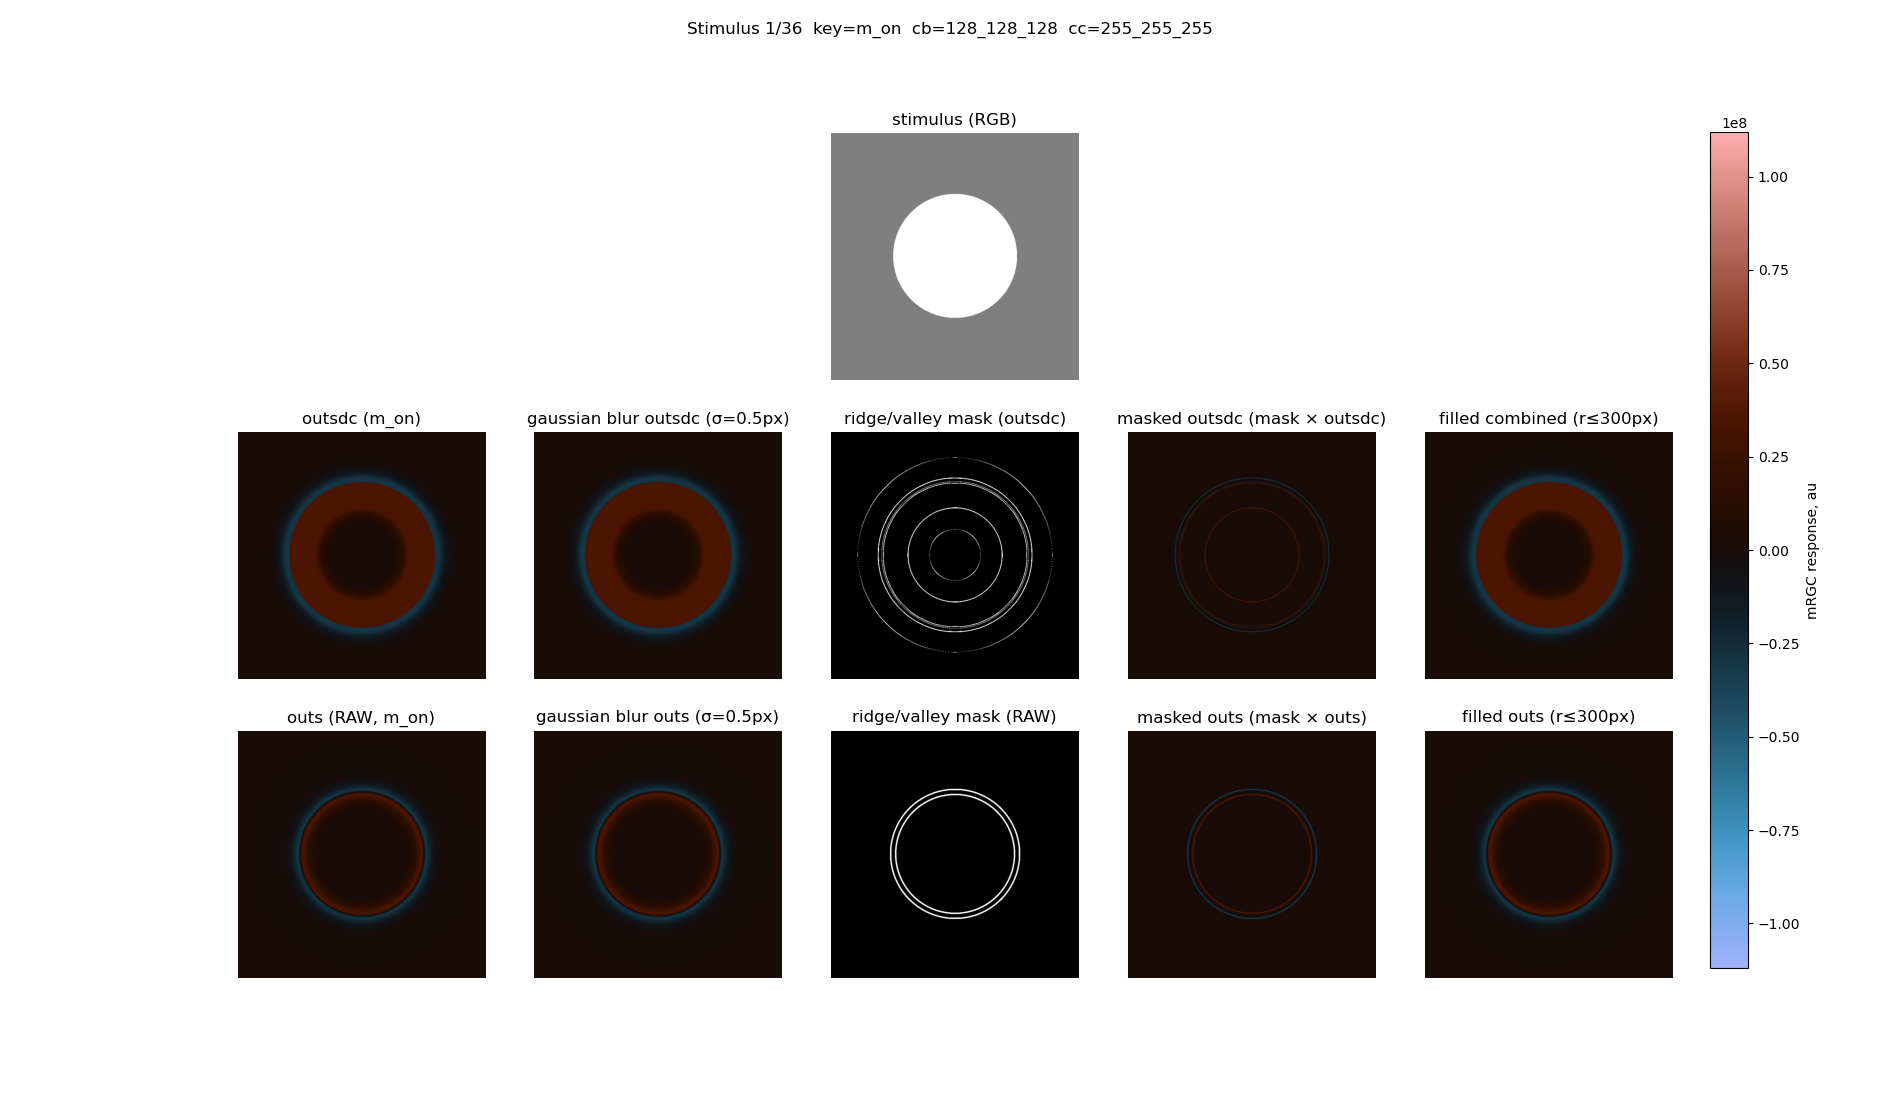

In [21]:
# 16. Interactive viewer (choose which model key to view)
from datetime import datetime  # for timestamp
# ----------------------------
# USER SETTING: pick which model to view (change this anytime, then rerun this cell)
view_key = "m_on"   # e.g. "l_on", "m_off", "l_h2_on", ...

# ----------------------------

ts = datetime.now().strftime("%Y%m%d_%H%M%S")  # 20260113_184530
outdir = f"outputs_15c_viewer_{ts}"            # unique folder per run
os.makedirs(outdir, exist_ok=True)             # create folder
print("Saving to:", outdir)  

def rgb_code01(c):
    """Encode an RGB color in [0,1] as 0-255 integers for filenames."""
    c = np.asarray(c, dtype=float)
    c255 = np.round(255.0 * np.clip(c, 0.0, 1.0)).astype(int)
    return f"{c255[0]:03d}_{c255[1]:03d}_{c255[2]:03d}"

# ----------------------------
# Compute ONE shared symmetric color scale across ALL stimuli for THIS view_key
global_abs_max = 0.0
for r in results:
    k = view_key  # (CHANGE) use the chosen key

    # DC set
    for A in (r["outsdc"][k], r["outsdc_smooth"][k], r["outsdc_extrema_weighted"][k], r["outsdc_filled"][k]):
        global_abs_max = max(global_abs_max, float(np.max(np.abs(A))))

    # RAW set
    for A in (r["outs"][k], r["outs_smooth"][k], r["outs_extrema_weighted"][k], r["outs_filled"][k]):
        global_abs_max = max(global_abs_max, float(np.max(np.abs(A))))

#vmin_all,vmax_all = -1e7, 1e7
vmin_all, vmax_all = -global_abs_max, global_abs_max

# ----------------------------
# Build the figure once (3 rows x 5 cols)
fig, axs = plt.subplots(3, 5, figsize=(19, 11), sharex=True, sharey=True)

# top row axes off by default
for j in range(5):
    axs[0, j].axis("off")

# stimulus (RGB)
stim_im = axs[0, 2].imshow(results[0]["imgs"], origin="lower")
axs[0, 2].set_title("stimulus (RGB)")
axs[0, 2].axis("off")

# ----------------------------
# Initialize image handles using the chosen key
r0 = results[0]
k = view_key  # chosen model key

# DC row (row=1)
dc0 = axs[1, 0].imshow(r0["outsdc"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 0].axis("off")
dc1 = axs[1, 1].imshow(r0["outsdc_smooth"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 1].axis("off")
dc2 = axs[1, 2].imshow(r0["outsdc_extrema_mask"][k].astype(float), origin="lower", cmap="gray", vmin=0.0, vmax=1.0); axs[1, 2].axis("off")
dc3 = axs[1, 3].imshow(r0["outsdc_extrema_weighted"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 3].axis("off")
# dc4 = axs[1, 4].imshow(r0["outsdc_filled"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 4].axis("off")
dc4 = axs[1, 4].imshow(r0["outs_combined_filled"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 4].axis("off")

# RAW row (row=2)
raw0 = axs[2, 0].imshow(r0["outs"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[2, 0].axis("off")
raw1 = axs[2, 1].imshow(r0["outs_smooth"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[2, 1].axis("off")
raw2 = axs[2, 2].imshow(r0["outs_extrema_mask"][k].astype(float), origin="lower", cmap="gray", vmin=0.0, vmax=1.0); axs[2, 2].axis("off")
raw3 = axs[2, 3].imshow(r0["outs_extrema_weighted"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[2, 3].axis("off")
raw4 = axs[2, 4].imshow(r0["outs_filled"][k], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[2, 4].axis("off")

# Titles (include the chosen key)
axs[1, 0].set_title(f"outsdc ({k})")
axs[1, 1].set_title(f"gaussian blur outsdc (σ={sigma_px}px)")
axs[1, 2].set_title("ridge/valley mask (outsdc)")
axs[1, 3].set_title("masked outsdc (mask × outsdc)")
axs[1, 4].set_title(f"filled combined (r≤{fill_radius_px}px)") # changed the title to match

axs[2, 0].set_title(f"outs (RAW, {k})")
axs[2, 1].set_title(f"gaussian blur outs (σ={sigma_px}px)")
axs[2, 2].set_title("ridge/valley mask (RAW)")
axs[2, 3].set_title("masked outs (mask × outs)")
axs[2, 4].set_title(f"filled outs (r≤{fill_radius_px}px)")

# One shared colorbar at far right (for response-like panels)
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
cbar = fig.colorbar(dc0, cax=cax)
cbar.set_label("mRGC response, au")

# ----------------------------
state = {"i": 0, "N": len(results)}

def update(i):
    r = results[i]
    k = view_key  # (CHANGE) chosen model key

    # stimulus
    stim_im.set_data(r["imgs"])

    # DC row
    dc0.set_data(r["outsdc"][k])
    dc1.set_data(r["outsdc_smooth"][k])
    dc2.set_data(r["outsdc_extrema_mask"][k].astype(float))
    dc3.set_data(r["outsdc_extrema_weighted"][k])
    # dc4.set_data(r["outsdc_filled"][k])
    dc4.set_data(r["outs_combined_filled"][k])
    
    # RAW row
    raw0.set_data(r["outs"][k])
    raw1.set_data(r["outs_smooth"][k])
    raw2.set_data(r["outs_extrema_mask"][k].astype(float))
    raw3.set_data(r["outs_extrema_weighted"][k])
    raw4.set_data(r["outs_filled"][k])

    # title with stimulus info + key
    cb = rgb_code01(r["colorbg"])
    cc = rgb_code01(r["colorcenter"])
    fig.suptitle(f"Stimulus {i+1}/{state['N']}  key={k}  cb={cb}  cc={cc}", fontsize=12)

    fig.canvas.draw_idle()

def save_current(i, dpi=200):
    r = results[i]
    k = view_key  # (CHANGE) chosen model key
    cb = rgb_code01(r["colorbg"])
    cc = rgb_code01(r["colorcenter"])
    fname = f"cb{cb}_cc{cc}_key{k}_15c.png"
    fpath = os.path.join(outdir, fname)
    fig.savefig(fpath, dpi=dpi, bbox_inches="tight")
    print(f"Saved {fpath}")

def on_key(event):
    if event.key in ("right", "n", " "):
        state["i"] = (state["i"] + 1) % state["N"]
        update(state["i"])
    elif event.key in ("left", "p", "backspace"):
        state["i"] = (state["i"] - 1) % state["N"]
        update(state["i"])
    elif event.key == "s":
        save_current(state["i"])
    elif event.key in ("q", "escape"):
        plt.close(fig)

fig.canvas.mpl_connect("key_press_event", on_key)

update(0)
plt.show()
